<a href="https://colab.research.google.com/github/MariaPetrovskaya/Data-Science-demo/blob/main/hypothesis_testing_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hypothesis Testing — Focused Demo
# Проверка статистических гипотез — фокусированное демо

**EN.** A compact, self-contained demonstration of statistical hypothesis-testing skills: formulating H0/H1, checking assumptions (normality via bootstrap + Shapiro–Wilk), choosing between parametric and non-parametric tests, running the test, and interpreting the p-value. Extracted and refactored from a larger vacancy-market analysis project for an HR agency.

**RU.** Компактная самодостаточная демонстрация навыка проверки статистических гипотез: формулировка H0/H1, проверка предпосылок (нормальность через бутстрап + критерий Шапиро–Уилка), выбор между параметрическим и непараметрическим тестом, проведение теста и интерпретация p-value. Собрано на основе более крупного проекта по анализу рынка вакансий для HR-агентства.

**Note / Примечание.** The original data lived in a private Google Drive export. This notebook uses a **synthetic dataset** that reproduces the structure and statistical character (skewed view counts, imbalanced groups) of the original, purely for demonstration. / Исходные данные хранились в приватной Google Drive-выгрузке. В этом ноутбуке используется **синтетический датасет**, воспроизводящий структуру и статистический характер оригинала (скошенное распределение просмотров, несбалансированные группы) — исключительно для демонстрации.

**How to switch language / Как переключить язык:** set `LANG = 'en'` or `LANG = 'ru'` in the next code cell, then **Run All**.


In [ ]:
# ============================================================
#  LANGUAGE SWITCH  /  ПЕРЕКЛЮЧЕНИЕ ЯЗЫКА
#  Set to 'ru' or 'en', then Kernel -> Restart & Run All
# ============================================================
LANG = 'ru'   # 'ru' or 'en'


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_style('whitegrid')
ALPHA = 0.05          # significance level / уровень значимости
N_BOOT = 500           # bootstrap resamples for the mean / число бутстрап-повторов для среднего


In [ ]:
TEXTS = {
    'ru': {
        'data_header': "## 1. Данные (синтетические)",
        'data_intro': (
            "Датасет воспроизводит структуру реального проекта: вакансии со столбцом "
            "**«число просмотров»** (сильно скошенное распределение — много вакансий с малым "
            "числом просмотров и немного «вирусных») и несколькими бинарными/числовыми признаками."
        ),
        'data_columns': "**Столбцы:** `views` — число просмотров; `remote_work` — есть ли удалёнка; "
                         "`full_employment` — полная занятость; `moscow_listed` — указана ли Москва среди городов; "
                         "`n_cities` — число городов в вакансии.",
        'hyp_header': "## 2. Проверка гипотез",
        'method_header': "### Как выбирается тест",
        'method_intro': (
            "Для сравнения двух групп по среднему значению нельзя просто сравнить средние "
            "«на глаз» — нужно понять, применим ли t-тест (он предполагает приблизительную "
            "нормальность распределения выборочного среднего) или лучше использовать "
            "непараметрический критерий Манна-Уитни.\n\n"
            "Подход: многократно (бутстрап, с возвращением) пересэмплируем каждую группу и считаем "
            "среднее — получаем распределение выборочного среднего. Проверяем его на нормальность "
            "критерием Шапиро-Уилка. Если для **обеих** групп p-value > α — распределение средних "
            "не отличается от нормального значимо, и мы используем t-тест Стьюдента (Уэлча). "
            "Иначе — критерий Манна-Уитни."
        ),
        'h1_title': "#### Гипотеза 1. Удалённая работа и число просмотров",
        'h1_h0': "H0: среднее число просмотров у вакансий с удалённой работой равно среднему числу просмотров у вакансий без неё.",
        'h1_h1': "H1: среднее число просмотров у вакансий с удалённой работой не равно среднему числу просмотров у вакансий без неё.",
        'h2_title': "#### Гипотеза 2. Полная занятость и число просмотров",
        'h2_h0': "H0: среднее число просмотров у вакансий с полной занятостью равно среднему числу просмотров у вакансий без неё.",
        'h2_h1': "H1: среднее число просмотров у вакансий с полной занятостью не равно среднему числу просмотров у вакансий без неё.",
        'h3_title': "#### Гипотеза 3. Упоминание Москвы и число просмотров",
        'h3_h0': "H0: среднее число просмотров у вакансий, где среди городов указана Москва, равно среднему числу просмотров у вакансий без неё.",
        'h3_h1': "H1: среднее число просмотров у вакансий, где среди городов указана Москва, не равно среднему числу просмотров у вакансий без неё.",
        'h4_title': "#### Гипотеза 4. Число городов и число просмотров (корреляция)",
        'h4_h0': "H0: связь между числом городов, в которых опубликована вакансия, и числом просмотров отсутствует (ρ = 0).",
        'h4_h1': "H1: связь между числом городов и числом просмотров существует (ρ ≠ 0).",
        'h4_method': (
            "Для выбора коэффициента корреляции проверяем нормальность обеих переменных "
            "критерием Шапиро-Уилка: если обе распределены нормально — коэффициент Пирсона, "
            "иначе — Спирмена (устойчив к выбросам и монотонным нелинейным связям)."
        ),
        'group_sizes': "Размеры групп: **{name1}** — n={n1}; **{name2}** — n={n2}.",
        'boot_result': "Бутстрап-нормальность выборочного среднего: **{name1}** p={p1:.4f} ({v1}); **{name2}** p={p2:.4f} ({v2}).",
        'normal_yes': "похоже на нормальное",
        'normal_no': "не похоже на нормальное",
        'test_chosen_t': "→ Обе группы проходят проверку на нормальность средних (p > {alpha}) — используем **t-тест Стьюдента (Уэлча)**.",
        'test_chosen_mw': "→ Хотя бы одна группа не проходит проверку на нормальность средних (p ≤ {alpha}) — используем **критерий Манна-Уитни**.",
        'test_result_header': "**Результат теста:**",
        'test_result': "статистика = {stat:.3f}, p-value = {p:.4f}",
        'conclusion_reject': (
            "**Вывод:** p-value ({p:.4f}) меньше уровня значимости α={alpha} → **отвергаем H0**. "
            "Различие статистически значимо."
        ),
        'conclusion_fail': (
            "**Вывод:** p-value ({p:.4f}) больше уровня значимости α={alpha} → **не удалось отвергнуть H0**. "
            "Статистически значимого различия не обнаружено."
        ),
        'corr_normal_header': "**Проверка нормальности переменных (Шапиро-Уилк):**",
        'corr_normal_result': "{name}: p={p:.4f} ({v})",
        'corr_method_pearson': "→ Обе переменные похожи на нормальные — используем **коэффициент Пирсона**.",
        'corr_method_spearman': "→ Хотя бы одна переменная не похожа на нормальную — используем **коэффициент Спирмена**.",
        'corr_result': "**Результат:** коэффициент корреляции = {stat:.3f}, p-value = {p:.4f}",
        'corr_conclusion_reject': (
            "**Вывод:** p-value ({p:.4f}) меньше α={alpha} → **отвергаем H0**. "
            "Статистически значимая связь обнаружена (коэффициент = {stat:.3f})."
        ),
        'corr_conclusion_fail': (
            "**Вывод:** p-value ({p:.4f}) больше α={alpha} → **не удалось отвергнуть H0**. "
            "Статистически значимой связи не обнаружено."
        ),
        'summary_header': "## 3. Итоговая таблица",
        'summary_intro': "Сводка всех проверенных гипотез:",
        'col_hypothesis': "Гипотеза", 'col_test': "Тест", 'col_pvalue': "p-value", 'col_verdict': "Вывод",
        'verdict_reject': "H0 отвергнута", 'verdict_fail': "H0 не отвергнута",
    },
    'en': {
        'data_header': "## 1. Data (synthetic)",
        'data_intro': (
            "The dataset mirrors the structure of the real project: job postings with a "
            "**'views'** column (strongly right-skewed — many postings with few views and a "
            "handful of 'viral' ones) plus several binary/numeric features."
        ),
        'data_columns': "**Columns:** `views` — number of views; `remote_work` — remote option available; "
                         "`full_employment` — full-time employment; `moscow_listed` — Moscow among listed cities; "
                         "`n_cities` — number of cities the posting targets.",
        'hyp_header': "## 2. Hypothesis testing",
        'method_header': "### How the test is chosen",
        'method_intro': (
            "You can't just eyeball two group means — you need to know whether a t-test is "
            "appropriate (it assumes the sampling distribution of the mean is roughly normal) "
            "or whether a non-parametric Mann-Whitney test is safer.\n\n"
            "Approach: bootstrap-resample each group (with replacement) many times and record "
            "the mean each time — this gives the sampling distribution of the mean. Test it for "
            "normality with Shapiro-Wilk. If **both** groups pass (p-value > α), the means are "
            "not distinguishable from normal, and we use Welch's t-test. Otherwise, Mann-Whitney U."
        ),
        'h1_title': "#### Hypothesis 1. Remote work and number of views",
        'h1_h0': "H0: the mean number of views for postings with a remote-work option equals the mean for postings without it.",
        'h1_h1': "H1: the mean number of views for postings with a remote-work option differs from the mean for postings without it.",
        'h2_title': "#### Hypothesis 2. Full-time employment and number of views",
        'h2_h0': "H0: the mean number of views for full-time postings equals the mean for non-full-time postings.",
        'h2_h1': "H1: the mean number of views for full-time postings differs from the mean for non-full-time postings.",
        'h3_title': "#### Hypothesis 3. Moscow mentioned and number of views",
        'h3_h0': "H0: the mean number of views for postings that list Moscow equals the mean for postings that don't.",
        'h3_h1': "H1: the mean number of views for postings that list Moscow differs from the mean for postings that don't.",
        'h4_title': "#### Hypothesis 4. Number of cities and number of views (correlation)",
        'h4_h0': "H0: there is no association between the number of cities a posting targets and its number of views (ρ = 0).",
        'h4_h1': "H1: there is an association between the two (ρ ≠ 0).",
        'h4_method': (
            "To pick the correlation coefficient, we test both variables for normality with "
            "Shapiro-Wilk: if both are normal, use Pearson's r; otherwise use Spearman's ρ "
            "(robust to outliers and monotonic non-linear relationships)."
        ),
        'group_sizes': "Group sizes: **{name1}** — n={n1}; **{name2}** — n={n2}.",
        'boot_result': "Bootstrap normality of the sample mean: **{name1}** p={p1:.4f} ({v1}); **{name2}** p={p2:.4f} ({v2}).",
        'normal_yes': "looks normal",
        'normal_no': "does not look normal",
        'test_chosen_t': "→ Both groups pass the normality check on their means (p > {alpha}) — using **Welch's t-test**.",
        'test_chosen_mw': "→ At least one group fails the normality check (p ≤ {alpha}) — using **Mann-Whitney U**.",
        'test_result_header': "**Test result:**",
        'test_result': "statistic = {stat:.3f}, p-value = {p:.4f}",
        'conclusion_reject': (
            "**Conclusion:** p-value ({p:.4f}) is below the significance level α={alpha} → **reject H0**. "
            "The difference is statistically significant."
        ),
        'conclusion_fail': (
            "**Conclusion:** p-value ({p:.4f}) is above the significance level α={alpha} → **fail to reject H0**. "
            "No statistically significant difference was found."
        ),
        'corr_normal_header': "**Normality check for both variables (Shapiro-Wilk):**",
        'corr_normal_result': "{name}: p={p:.4f} ({v})",
        'corr_method_pearson': "→ Both variables look normal — using **Pearson's r**.",
        'corr_method_spearman': "→ At least one variable doesn't look normal — using **Spearman's ρ**.",
        'corr_result': "**Result:** correlation coefficient = {stat:.3f}, p-value = {p:.4f}",
        'corr_conclusion_reject': (
            "**Conclusion:** p-value ({p:.4f}) is below α={alpha} → **reject H0**. "
            "A statistically significant association was found (coefficient = {stat:.3f})."
        ),
        'corr_conclusion_fail': (
            "**Conclusion:** p-value ({p:.4f}) is above α={alpha} → **fail to reject H0**. "
            "No statistically significant association was found."
        ),
        'summary_header': "## 3. Summary table",
        'summary_intro': "Overview of all hypotheses tested:",
        'col_hypothesis': "Hypothesis", 'col_test': "Test", 'col_pvalue': "p-value", 'col_verdict': "Verdict",
        'verdict_reject': "H0 rejected", 'verdict_fail': "H0 not rejected",
    },
}

def T(key, **kwargs):
    text = TEXTS[LANG][key]
    return text.format(**kwargs) if kwargs else text

def show(key, **kwargs):
    display(Markdown(T(key, **kwargs)))

def show_raw(text):
    display(Markdown(text))

In [ ]:
show('data_header')

## 1. Данные (синтетические)

In [ ]:
show('data_intro'); show('data_columns')

Датасет воспроизводит структуру реального проекта: вакансии со столбцом **«число просмотров»** (сильно скошенное распределение — много вакансий с малым числом просмотров и немного «вирусных») и несколькими бинарными/числовыми признаками.

**Столбцы:** `views` — число просмотров; `remote_work` — есть ли удалёнка; `full_employment` — полная занятость; `moscow_listed` — указана ли Москва среди городов; `n_cities` — число городов в вакансии.

In [ ]:

rng = np.random.default_rng(1)
n = 1200

remote_work = rng.choice([True, False], size=n, p=[0.35, 0.65])
full_employment = rng.choice([True, False], size=n, p=[0.85, 0.15])
moscow_listed = rng.choice([True, False], size=n, p=[0.30, 0.70])
n_cities = rng.poisson(lam=1.4, size=n) + 1

base = rng.lognormal(mean=3.0, sigma=1.0, size=n)
views = base.copy()
views = views + np.where(remote_work, rng.lognormal(mean=2.3, sigma=1.0, size=n), 0)
views = views + np.where(full_employment, -rng.exponential(scale=9, size=n), 0)
views = np.clip(views, 0, None)
views = np.round(views).astype(int)

df = pd.DataFrame({
    'views': views,
    'remote_work': remote_work,
    'full_employment': full_employment,
    'moscow_listed': moscow_listed,
    'n_cities': n_cities,
})
df.head()


,views,remote_work,full_employment,moscow_listed,n_cities
0,18,False,True,False,4
1,10,False,True,False,1
2,19,True,True,True,3
3,2,False,True,True,2
4,46,True,True,False,2


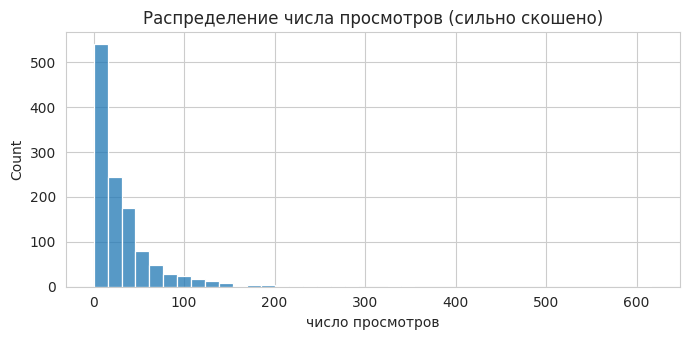

In [ ]:

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(df['views'], bins=40, ax=ax)
ax.set_title({'ru': 'Распределение числа просмотров (сильно скошено)', 'en': 'Distribution of views (strongly skewed)'}[LANG])
ax.set_xlabel({'ru': 'число просмотров', 'en': 'views'}[LANG])
plt.tight_layout()
plt.show()


In [ ]:
show('hyp_header')

## 2. Проверка гипотез

In [ ]:
show('method_header'); show('method_intro')

### Как выбирается тест

Для сравнения двух групп по среднему значению нельзя просто сравнить средние «на глаз» — нужно понять, применим ли t-тест (он предполагает приблизительную нормальность распределения выборочного среднего) или лучше использовать непараметрический критерий Манна-Уитни.

Подход: многократно (бутстрап, с возвращением) пересэмплируем каждую группу и считаем среднее — получаем распределение выборочного среднего. Проверяем его на нормальность критерием Шапиро-Уилка. Если для **обеих** групп p-value > α — распределение средних не отличается от нормального значимо, и мы используем t-тест Стьюдента (Уэлча). Иначе — критерий Манна-Уитни.

In [ ]:
def bootstrap_mean_pvalue(sample, n_boot=N_BOOT, rng=rng):
    # Bootstrap the sampling distribution of the mean and test it for normality.
    sample = np.asarray(sample)
    boot_means = np.array([
        rng.choice(sample, size=len(sample), replace=True).mean()
        for _ in range(n_boot)
    ])
    return stats.shapiro(boot_means).pvalue


def run_two_sample_hypothesis(group1, group2, name1, name2):
    # Full pipeline: normality check -> test selection -> run test -> print conclusion.
    show('group_sizes', name1=name1, name2=name2, n1=len(group1), n2=len(group2))

    p1 = bootstrap_mean_pvalue(group1)
    p2 = bootstrap_mean_pvalue(group2)
    v1 = T('normal_yes') if p1 > ALPHA else T('normal_no')
    v2 = T('normal_yes') if p2 > ALPHA else T('normal_no')
    show('boot_result', name1=name1, name2=name2, p1=p1, p2=p2, v1=v1, v2=v2)

    if p1 > ALPHA and p2 > ALPHA:
        show('test_chosen_t', alpha=ALPHA)
        result = stats.ttest_ind(group1, group2, equal_var=False)
        test_name = "Welch t-test"
    else:
        show('test_chosen_mw', alpha=ALPHA)
        result = stats.mannwhitneyu(group1, group2)
        test_name = "Mann-Whitney U"

    show('test_result_header')
    show_raw(T('test_result', stat=result.statistic, p=result.pvalue))

    if result.pvalue < ALPHA:
        show('conclusion_reject', p=result.pvalue, alpha=ALPHA)
        verdict = T('verdict_reject')
    else:
        show('conclusion_fail', p=result.pvalue, alpha=ALPHA)
        verdict = T('verdict_fail')

    return {'test': test_name, 'p_value': result.pvalue, 'verdict': verdict}


def run_correlation_hypothesis(x, y, name_x, name_y):
    show('corr_normal_header')
    px = stats.shapiro(x).pvalue
    py = stats.shapiro(y).pvalue
    vx = T('normal_yes') if px > ALPHA else T('normal_no')
    vy = T('normal_yes') if py > ALPHA else T('normal_no')
    show_raw(T('corr_normal_result', name=name_x, p=px, v=vx))
    show_raw(T('corr_normal_result', name=name_y, p=py, v=vy))

    if px > ALPHA and py > ALPHA:
        show('corr_method_pearson')
        stat, p = stats.pearsonr(x, y)
        test_name = "Pearson r"
    else:
        show('corr_method_spearman')
        stat, p = stats.spearmanr(x, y)
        test_name = "Spearman rho"

    show('corr_result', stat=stat, p=p)

    if p < ALPHA:
        show('corr_conclusion_reject', p=p, alpha=ALPHA, stat=stat)
        verdict = T('verdict_reject')
    else:
        show('corr_conclusion_fail', p=p, alpha=ALPHA)
        verdict = T('verdict_fail')

    return {'test': test_name, 'p_value': p, 'verdict': verdict}


results = {}

In [ ]:
show('h1_title'); show_raw(T('h1_h0')); show_raw(T('h1_h1'))

#### Гипотеза 1. Удалённая работа и число просмотров

H0: среднее число просмотров у вакансий с удалённой работой равно среднему числу просмотров у вакансий без неё.

H1: среднее число просмотров у вакансий с удалённой работой не равно среднему числу просмотров у вакансий без неё.

In [ ]:

g_remote = df.loc[df['remote_work'], 'views']
g_not_remote = df.loc[~df['remote_work'], 'views']
results['H1'] = run_two_sample_hypothesis(
    g_remote, g_not_remote,
    {'ru': 'с удалёнкой', 'en': 'remote'}[LANG],
    {'ru': 'без удалёнки', 'en': 'not remote'}[LANG],
)


Размеры групп: **с удалёнкой** — n=410; **без удалёнки** — n=790.

Бутстрап-нормальность выборочного среднего: **с удалёнкой** p=0.4374 (похоже на нормальное); **без удалёнки** p=0.2271 (похоже на нормальное).

→ Обе группы проходят проверку на нормальность средних (p > 0.05) — используем **t-тест Стьюдента (Уэлча)**.

**Результат теста:**

статистика = 6.845, p-value = 0.0000

**Вывод:** p-value (0.0000) меньше уровня значимости α=0.05 → **отвергаем H0**. Различие статистически значимо.

In [ ]:
show('h2_title'); show_raw(T('h2_h0')); show_raw(T('h2_h1'))

#### Гипотеза 2. Полная занятость и число просмотров

H0: среднее число просмотров у вакансий с полной занятостью равно среднему числу просмотров у вакансий без неё.

H1: среднее число просмотров у вакансий с полной занятостью не равно среднему числу просмотров у вакансий без неё.

In [ ]:

g_full = df.loc[df['full_employment'], 'views']
g_not_full = df.loc[~df['full_employment'], 'views']
results['H2'] = run_two_sample_hypothesis(
    g_full, g_not_full,
    {'ru': 'полная занятость', 'en': 'full-time'}[LANG],
    {'ru': 'не полная занятость', 'en': 'not full-time'}[LANG],
)


Размеры групп: **полная занятость** — n=1037; **не полная занятость** — n=163.

Бутстрап-нормальность выборочного среднего: **полная занятость** p=0.6388 (похоже на нормальное); **не полная занятость** p=0.3602 (похоже на нормальное).

→ Обе группы проходят проверку на нормальность средних (p > 0.05) — используем **t-тест Стьюдента (Уэлча)**.

**Результат теста:**

статистика = -2.421, p-value = 0.0163

**Вывод:** p-value (0.0163) меньше уровня значимости α=0.05 → **отвергаем H0**. Различие статистически значимо.

In [ ]:
show('h3_title'); show_raw(T('h3_h0')); show_raw(T('h3_h1'))

#### Гипотеза 3. Упоминание Москвы и число просмотров

H0: среднее число просмотров у вакансий, где среди городов указана Москва, равно среднему числу просмотров у вакансий без неё.

H1: среднее число просмотров у вакансий, где среди городов указана Москва, не равно среднему числу просмотров у вакансий без неё.

In [ ]:

g_msk = df.loc[df['moscow_listed'], 'views']
g_not_msk = df.loc[~df['moscow_listed'], 'views']
results['H3'] = run_two_sample_hypothesis(
    g_msk, g_not_msk,
    {'ru': 'есть Москва', 'en': 'Moscow listed'}[LANG],
    {'ru': 'нет Москвы', 'en': 'no Moscow'}[LANG],
)


Размеры групп: **есть Москва** — n=369; **нет Москвы** — n=831.

Бутстрап-нормальность выборочного среднего: **есть Москва** p=0.0001 (не похоже на нормальное); **нет Москвы** p=0.2034 (похоже на нормальное).

→ Хотя бы одна группа не проходит проверку на нормальность средних (p ≤ 0.05) — используем **критерий Манна-Уитни**.

**Результат теста:**

статистика = 141991.500, p-value = 0.0406

**Вывод:** p-value (0.0406) меньше уровня значимости α=0.05 → **отвергаем H0**. Различие статистически значимо.

In [ ]:
show('h4_title'); show_raw(T('h4_h0')); show_raw(T('h4_h1')); show_raw(T('h4_method'))

#### Гипотеза 4. Число городов и число просмотров (корреляция)

H0: связь между числом городов, в которых опубликована вакансия, и числом просмотров отсутствует (ρ = 0).

H1: связь между числом городов и числом просмотров существует (ρ ≠ 0).

Для выбора коэффициента корреляции проверяем нормальность обеих переменных критерием Шапиро-Уилка: если обе распределены нормально — коэффициент Пирсона, иначе — Спирмена (устойчив к выбросам и монотонным нелинейным связям).

In [ ]:

results['H4'] = run_correlation_hypothesis(
    df['n_cities'].values, df['views'].values,
    {'ru': 'число городов', 'en': 'n_cities'}[LANG],
    {'ru': 'число просмотров', 'en': 'views'}[LANG],
)


**Проверка нормальности переменных (Шапиро-Уилк):**

число городов: p=0.0000 (не похоже на нормальное)

число просмотров: p=0.0000 (не похоже на нормальное)

→ Хотя бы одна переменная не похожа на нормальную — используем **коэффициент Спирмена**.

**Результат:** коэффициент корреляции = -0.000, p-value = 0.9940

**Вывод:** p-value (0.9940) больше α=0.05 → **не удалось отвергнуть H0**. Статистически значимой связи не обнаружено.

In [ ]:
show('summary_header'); show('summary_intro')

## 3. Итоговая таблица

Сводка всех проверенных гипотез:

In [ ]:

hyp_labels = {
    'H1': T('h1_title').lstrip('#').strip(),
    'H2': T('h2_title').lstrip('#').strip(),
    'H3': T('h3_title').lstrip('#').strip(),
    'H4': T('h4_title').lstrip('#').strip(),
}

summary = pd.DataFrame([
    {
        T('col_hypothesis'): hyp_labels[k],
        T('col_test'): v['test'],
        T('col_pvalue'): round(v['p_value'], 4),
        T('col_verdict'): v['verdict'],
    }
    for k, v in results.items()
])
summary


,Гипотеза,Тест,p-value,Вывод
0,Гипотеза 1. Удалённая работа и число просмотров,Welch t-test,0.0000,H0 отвергнута
1,Гипотеза 2. Полная занятость и число просмотров,Welch t-test,0.0163,H0 отвергнута
2,Гипотеза 3. Упоминание Москвы и число просмотров,Mann-Whitney U,0.0406,H0 отвергнута
3,Гипотеза 4. Число городов и число просмотров (...,Spearman rho,0.9940,H0 не отвергнута


---
**EN.** This notebook is intentionally narrow: its only job is to show the mechanics of hypothesis testing (H0/H1, assumption checks, test selection, interpretation) cleanly and reproducibly. The broader exploratory analysis, feature engineering, and NLP work live in the source project.

**RU.** Этот ноутбук намеренно узкий: его единственная задача — чисто и воспроизводимо показать механику проверки гипотез (H0/H1, проверка предпосылок, выбор теста, интерпретация). Более широкий разведочный анализ, генерация признаков и NLP-часть остались в исходном проекте.
